Install Libraries

In [ ]:
!pip install kagglehub openpyxl scikit-learn grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Imports & Device

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


Download Dataset

In [ ]:
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")

train_image_dir = os.path.join(path, "ODIR-5K", "ODIR-5K", "Training Images")
csv_path = os.path.join(path, "full_df.csv")

df = pd.read_csv(csv_path)

label_columns = ['N','D','G','C','A','H','M','O']
df = df[['Left-Fundus','Right-Fundus'] + label_columns]

data = []

for _, row in df.iterrows():
    labels = row[label_columns].values.astype('float32')
    data.append([row['Left-Fundus'], labels])
    data.append([row['Right-Fundus'], labels])

dataset_df = pd.DataFrame(data, columns=['image','labels'])

dataset_df = dataset_df[
    dataset_df['image'].apply(
        lambda x: os.path.exists(os.path.join(train_image_dir, x))
    )
]

train_df, val_df = train_test_split(dataset_df, test_size=0.2, random_state=42)

100%|██████████| 1.62G/1.62G [00:19<00:00, 91.0MB/s]

Extracting files...


Transforms (Corrected Normalization)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

Dataset Class (Auto Severity)

In [ ]:
class ODIRDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image']
        labels = self.df.loc[idx, 'labels']

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(labels, dtype=torch.float32)

        severity = torch.mean(labels)

        return image, labels, severity

Data Loaders

In [ ]:
train_dataset = ODIRDataset(train_df, train_image_dir, train_transform)
val_dataset = ODIRDataset(val_df, train_image_dir, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

SE Attention Block

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        y = F.relu(self.fc1(x))
        y = torch.sigmoid(self.fc2(y))
        return x * y

Multi-Task Model

In [ ]:
class MultiTaskModel(nn.Module):
    def __init__(self):
        super(MultiTaskModel, self).__init__()

        self.backbone = models.resnet50(pretrained=True)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.attention = SEBlock(in_features)

        self.disease_head = nn.Linear(in_features, 8)

        self.severity_head = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        features = self.attention(features)

        disease_out = self.disease_head(features)
        severity_out = self.severity_head(features)

        return disease_out, severity_out

Loss Functions

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE)
        focal = self.alpha * (1-pt)**self.gamma * BCE
        return focal.mean()

model = MultiTaskModel().to(device)

disease_loss = FocalLoss()
severity_loss = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


Training

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels, severity in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        severity = severity.unsqueeze(1).to(device)

        optimizer.zero_grad()

        disease_out, severity_out = model(images)

        loss1 = disease_loss(disease_out, labels)
        loss2 = severity_loss(severity_out, severity)

        loss = loss1 + 0.5 * loss2
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")


100%|██████████| 320/320 [10:00<00:00,  1.88s/it]


Epoch 1, Loss: 0.08179894118802622


100%|██████████| 320/320 [09:24<00:00,  1.77s/it]


Epoch 2, Loss: 0.06825471363263205


100%|██████████| 320/320 [09:22<00:00,  1.76s/it]


...

Epoch 28, Loss: 0.006300883060248452


100%|██████████| 320/320 [09:07<00:00,  1.71s/it]


Epoch 29, Loss: 0.007916743187706743


100%|██████████| 320/320 [09:12<00:00,  1.73s/it]

Epoch 30, Loss: 0.006060424032875744


Save Model

In [ ]:
torch.save(model.state_dict(), "eye_disease_model.pth")

Evaluation

In [ ]:
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs, _ = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)
all_probs = np.vstack(all_probs)

print("Micro F1:", f1_score(all_labels, all_preds, average='micro'))
print("Macro F1:", f1_score(all_labels, all_preds, average='macro'))


Micro F1: 0.8667234042553191
Macro F1: 0.8618316110823867


Prediction + Risk

In [ ]:
disease_names = ["Normal","Diabetes","Glaucoma","Cataract",
                 "AMD","Hypertension","Myopia","Other"]

def predict_image(image_path):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        disease_out, severity_out = model(image)
        probs = torch.sigmoid(disease_out)

    predicted = (probs > 0.5).int().cpu().numpy()[0]
    severity_score = severity_out.item()

    if severity_score > 0.7:
        risk = "High"
    elif severity_score > 0.4:
        risk = "Moderate"
    else:
        risk = "Low"

    print("\nPredicted Diseases:")
    for i, val in enumerate(predicted):
        if val == 1:
            print("-", disease_names[i])

    print("Severity Score:", round(severity_score,3))
    print("Risk Level:", risk)


Grad-CAM

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class GradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        disease_out, _ = self.model(x)
        return disease_out

def generate_heatmap(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = val_transform(image).unsqueeze(0).to(device)

    cam_model = GradCAMWrapper(model)
    target_layer = model.backbone.layer4[-1]

    cam = GradCAM(model=cam_model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    rgb_img = np.array(image.resize((224,224))) / 255.0
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6,6))
    plt.imshow(visualization)
    plt.axis("off")
    plt.title("Disease Attention Heatmap")
    plt.show()

Run Prediction


Predicted Diseases:
- Cataract
Severity Score: 0.121
Risk Level: Low


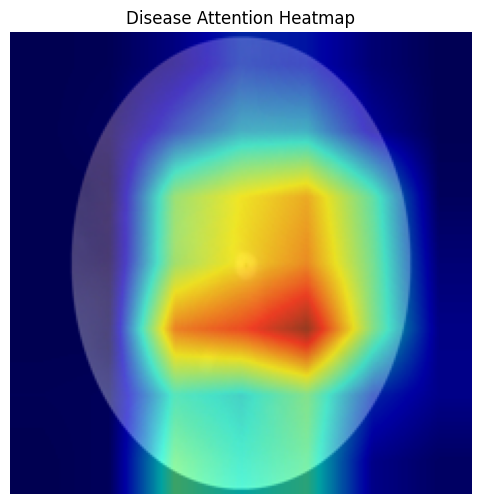

In [ ]:
test_image = os.path.join(train_image_dir, dataset_df.iloc[0]['image'])

predict_image(test_image)
generate_heatmap(test_image)

In [ ]:
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs, _ = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)
all_probs = np.vstack(all_probs)

# 🔹 METRICS
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='micro')
recall = recall_score(all_labels, all_preds, average='micro')
f1_micro = f1_score(all_labels, all_preds, average='micro')
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print("\n===== FINAL METRICS =====")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"Micro F1      : {f1_micro:.4f}")
print(f"Macro F1      : {f1_macro:.4f}")
print(f"Weighted F1   : {f1_weighted:.4f}")



===== FINAL METRICS =====
Accuracy      : 0.8475
Precision     : 0.8918
Recall        : 0.8792
Micro F1      : 0.8855
Macro F1      : 0.8878
Weighted F1   : 0.8850


Saving retinatest1.jpg to retinatest1.jpg
Uploaded: retinatest1.jpg

===== RESULTS =====
Detected Diseases:
- Diabetes (prob=0.52)
- Glaucoma (prob=0.52)
- Cataract (prob=0.52)
- AMD (prob=0.53)
- Hypertension (prob=0.52)
- Other (prob=0.51)

Severity Score : 0.544
Risk Level     : MODERATE RISK


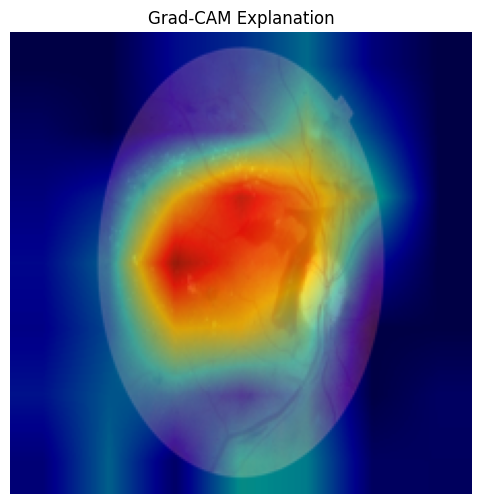

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

model.eval()

image = Image.open(img_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    disease_out, severity_out = model(input_tensor)
    probs = torch.sigmoid(disease_out).cpu().numpy()[0]
    severity_score = severity_out.item()

threshold = 0.5
predicted = np.where(probs > threshold)[0]

if severity_score >= 0.7:
    risk = "HIGH RISK"
elif severity_score >= 0.4:
    risk = "MODERATE RISK"
else:
    risk = "LOW RISK"

print("\n===== RESULTS =====")

if len(predicted) == 0:
    print("No major disease detected (Normal Eye)")
else:
    print("Detected Diseases:")
    for i in predicted:
        print(f"- {disease_names[i]} (prob={probs[i]:.2f})")

print(f"\nSeverity Score : {severity_score:.3f}")
print(f"Risk Level     : {risk}")

class GradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        disease_out, _ = self.model(x)
        return disease_out

target_layer = model.backbone.layer4[-1]
cam_model = GradCAMWrapper(model)
cam = GradCAM(model=cam_model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_img = np.array(image.resize((224,224))) / 255.0
heatmap = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(heatmap)
plt.title("Grad-CAM Explanation")
plt.axis('off')
plt.show()

AI Integration

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


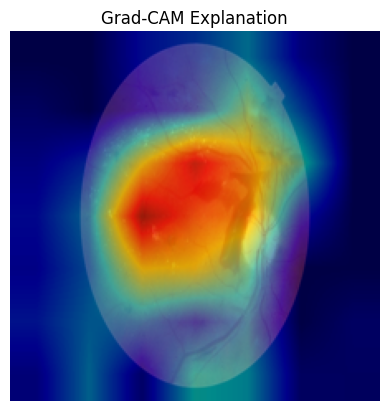

AI EYE DISEASE REPORT

INTERPRETATION
--------------
AMD is a condition where the retinal layers deteriorate and become infiltrated
with abnormal blood vessels, which can lead to retinal degeneration.

RISK
----
Without proper medical intervention, this condition can lead to blindness.
Ophthalmology expert on the risk of macular degeneration (AMD). Without proper
medical intervention, this condition can lead to glaucoma

HABITS
------
To protect your vision, you should strictly avoid smoking, drinking alcohol and
eating a diet high in refined sugars such as sweetened drinks.

DIET
----
Your daily nutrition should focus on consuming Omega-3 fatty acids (EPA and
DHEA) from fish, flaxseed oil.

MONITORING
----------
Professional monitoring requires a clinical visit every year to monitor the
condition of your ophthalmia. Your eye doctor may also visit you every 6 months


In [ ]:
import torch
import textwrap
import numpy as np
from transformers import T5Tokenizer, T5ForConditionalGeneration
import matplotlib.pyplot as plt

class EyeDiseaseGenAI:
    def __init__(self, model_name="google/flan-t5-large"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name).to(self.device)

    def generate_clinical_text(self, prompt, starter_text):
        full_input = f"Ophthalmology Expert: {prompt}. {starter_text}"
        inputs = self.tokenizer(full_input, return_tensors="pt").to(self.device)

        outputs = self.model.generate(
            **inputs,
            max_new_tokens=100,
            min_new_tokens=20,
            num_beams=5,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            early_stopping=True,
            do_sample=False
        )

        decoded = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

        cleaned = decoded.replace(f"Ophthalmology Expert: {prompt}.", "").strip()

        if cleaned.startswith(starter_text):
            return cleaned
        return f"{starter_text} {cleaned}"

gen_ai = EyeDiseaseGenAI()
plt.imshow(heatmap)
plt.title("Grad-CAM Explanation")
plt.axis('off')
plt.show()
try:
    max_idx = np.argmax(probs)
    top_condition = disease_names[max_idx]

    report_data = {
        "INTERPRETATION": gen_ai.generate_clinical_text(
            f"Explain {top_condition} pathology",
            f"{top_condition} is a condition where the retinal layers"
        ),
        "RISK": gen_ai.generate_clinical_text(
            f"Blindness risk of {top_condition}",
            f"Without proper medical intervention, this condition can lead to"
        ),
        "HABITS": gen_ai.generate_clinical_text(
            f"Lifestyle habits for {top_condition}",
            f"To protect your vision, you should strictly avoid"
        ),
        "DIET": gen_ai.generate_clinical_text(
            f"Best foods for {top_condition}",
            f"Your daily nutrition should focus on consuming"
        ),
        "MONITORING": gen_ai.generate_clinical_text(
            f"Doctor visit frequency for {top_condition} per year",
            f"Professional monitoring requires a clinical visit every"
        )
    }

    print("="*40 + "\nAI EYE DISEASE REPORT\n" + "="*40)
    for section, content in report_data.items():
        print(f"\n{section}\n" + "-"*len(section))
        print(textwrap.fill(content, width=80))

except NameError:
    print("Run the prediction cell first!")